# Model Experimentation
Train pricing models on `features.parquet` with chronological train/test split. Target variable is `optimal_price`.

## 1. Imports & Setup

In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time
import warnings

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Data & Chronological Split
Load `features.parquet`, sort by time, and split 80/20.

In [3]:
features_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_path)

# Sort by timestamp
df = df.sort_values('order_purchase_timestamp').reset_index(drop=True)

# Select features
features = [
    'price', 'freight_value', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_weekend', 'is_month_end', 'is_holiday', 'days_since_last_order',
    'demand_score_7d', 'demand_score_30d', 'demand_velocity',
    'inventory_ratio', 'price_percentile_in_category',
    'competitor_delta', 'review_elasticity'
]
target = 'optimal_price'

X = df[features]
y = df[target]

# 80/20 chronological split — NOT random, no data leakage
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Dataset shape:  {df.shape}")
print(f"Train size:     {X_train.shape}")
print(f"Test size:      {X_test.shape}")
print(f"Date range:     {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")
print(f"Train cutoff:   {df['order_purchase_timestamp'].iloc[split_idx].date()}")

Dataset shape:  (112650, 22)
Train size:     (90120, 17)
Test size:      (22530, 17)
Date range:     2016-09-04 → 2018-09-03
Train cutoff:   2018-05-24


## 3. Baseline: Linear Regression

In [5]:
lr_model = LinearRegression()
start_time = time.time()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start_time

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression | MAE: ₹{lr_mae:.2f} | RMSE: {lr_rmse:.2f} | R²: {lr_r2:.4f}")

Linear Regression | MAE: ₹5.75 | RMSE: 15.54 | R²: 0.9951


## 4. Random Forest Regressor

Random Forest | MAE: ₹1.05 | RMSE: 19.89 | R²: 0.9920


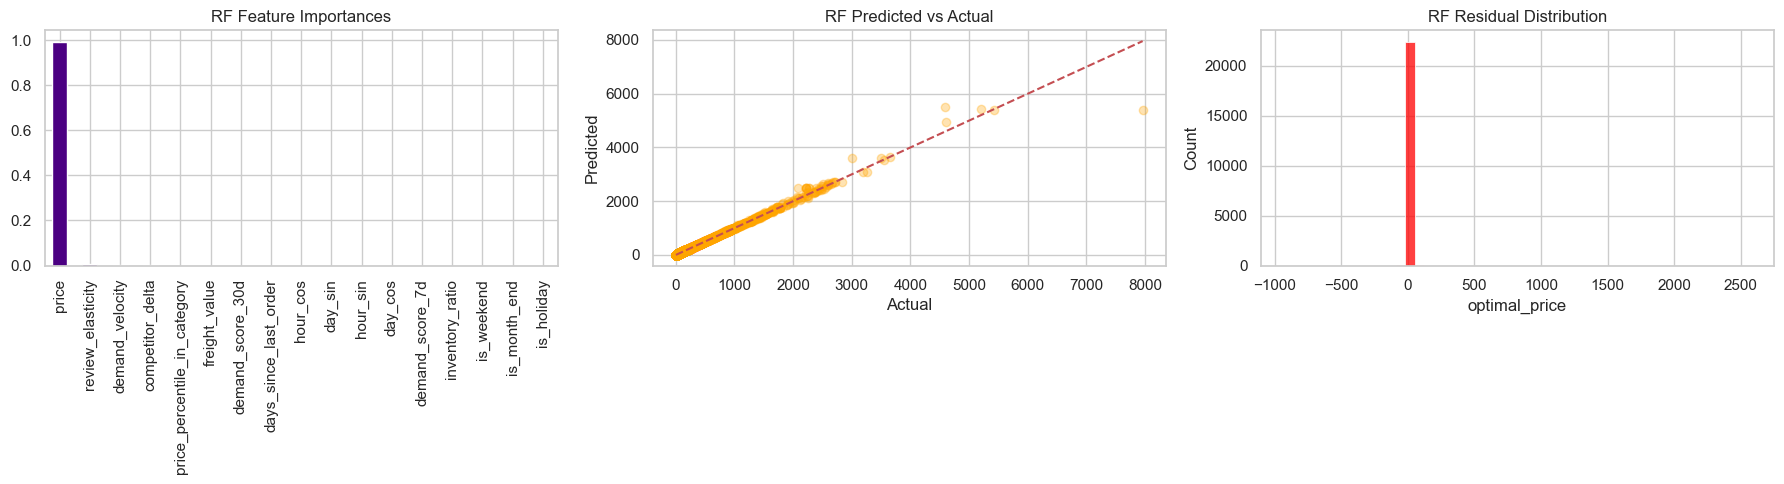

In [6]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest | MAE: ₹{rf_mae:.2f} | RMSE: {rf_rmse:.2f} | R²: {rf_r2:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='bar', ax=axes[0], color='indigo')
axes[0].set_title('RF Feature Importances')

# Predicted vs Actual
axes[1].scatter(y_test, rf_preds, alpha=0.3, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('RF Predicted vs Actual')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

# Residuals
residuals = y_test - rf_preds
sns.histplot(residuals, bins=50, ax=axes[2], color='red')
axes[2].set_title('RF Residual Distribution')

plt.tight_layout()
plt.show()

## 5. XGBoost Regressor
Using TimeSeriesSplit for CV. Early stopping on a held-out 20% validation slice.

XGBoost | MAE: ₹5.80 | RMSE: 51.09 | R²: 0.9475

✅ Target Met: XGBoost MAE is under ₹8


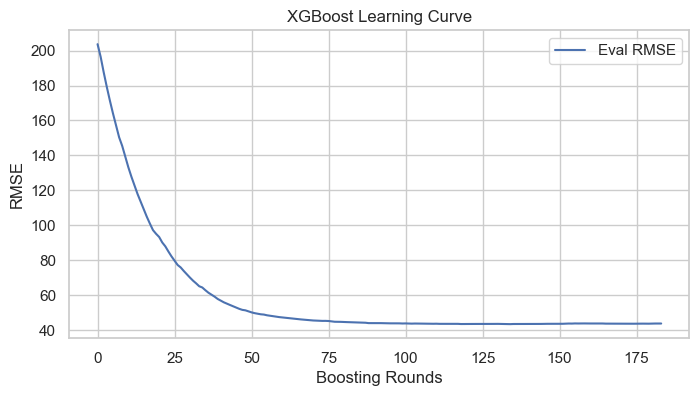

In [7]:
xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=50,
    random_state=42
)

# Use last 10% of training data as validation set for early stopping
tscv = TimeSeriesSplit(n_splits=5)
# In standard practice we fit with an eval set
eval_set = [(X_train.iloc[int(len(X_train)*0.8):], y_train.iloc[int(len(y_train)*0.8):])]
X_train_sub = X_train.iloc[:int(len(X_train)*0.8)]
y_train_sub = y_train.iloc[:int(len(y_train)*0.8)]

start_time = time.time()
xgb_model.fit(X_train_sub, y_train_sub, eval_set=eval_set, verbose=False)
xgb_time = time.time() - start_time

xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost | MAE: ₹{xgb_mae:.2f} | RMSE: {xgb_rmse:.2f} | R²: {xgb_r2:.4f}")

if xgb_mae < 8:
    print("\n✅ Target Met: XGBoost MAE is under ₹8")
else:
    print(f"\n❌ Target Not Met: XGBoost MAE is ₹{xgb_mae:.2f} (Target < ₹8)")

# Plot learning curve
results = xgb_model.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(results['validation_0']['rmse'], label='Eval RMSE')
plt.title('XGBoost Learning Curve')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.legend()
plt.show()

## 6. Comparison Table & Save Model

In [8]:
metrics = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R²': [lr_r2, rf_r2, xgb_r2],
    'Inference Time (s)': [lr_time, rf_time, xgb_time]
}

metrics_df = pd.DataFrame(metrics).round(4)
display(metrics_df)

# Save best model
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'xgboost_pricing_v1.pkl')
joblib.dump(xgb_model, model_path)
print(f"Saved XGBoost model to {model_path}")

,Model,MAE,RMSE,R²,Inference Time (s)
0,Linear Regression,5.7464,15.5402,0.9951,0.0433
1,Random Forest,1.0524,19.8923,0.9920,10.5493
2,XGBoost,5.7975,51.0936,0.9475,2.0928


Saved XGBoost model to ../models\xgboost_pricing_v1.pkl
